# Breast Cancer Classification using Machine Learning
Data: [sklearn breast cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

In [1]:
# check python version
import sys
import scipy
import numpy
import matplotlib
import pandas
import sklearn

# if any errors, must install the packages
print('Python: {}'.format(sys.version))
print('scipy: {}'.format(scipy.__version__))
print('numpy: {}'.format(numpy.__version__))
print('matplotlib: {}'.format(matplotlib.__version__))
print('pandas: {}'.format(pandas.__version__))
print('sklearn: {}'.format(sklearn.__version__))

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]
scipy: 1.13.1
numpy: 1.26.4
matplotlib: 3.10.0
pandas: 2.2.3
sklearn: 1.6.1


In [2]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score#, classification_report



In [3]:
cancer = datasets.load_breast_cancer()

In [4]:
print('dataset shape:\n', cancer.data.shape)
print('cancer dataset targets:\n', cancer.target_names)
print('cancer dataset features:\n', cancer.feature_names)
#print(cancer.DESCR)

dataset shape:
 (569, 30)
cancer dataset targets:
 ['malignant' 'benign']
cancer dataset features:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [5]:
df = datasets.load_breast_cancer(as_frame=True).frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


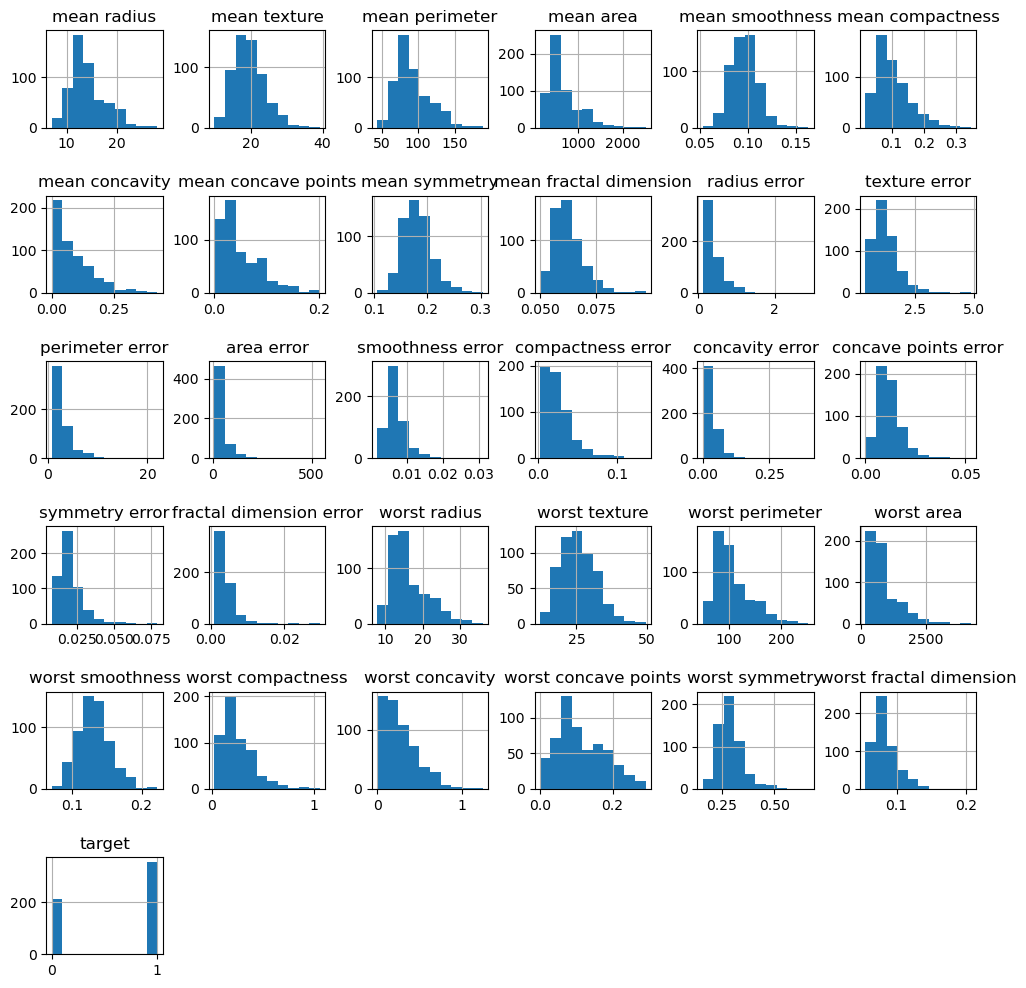

In [6]:
df.hist(figsize=(12,12))
plt.subplots_adjust(hspace=0.7, wspace=0.4);

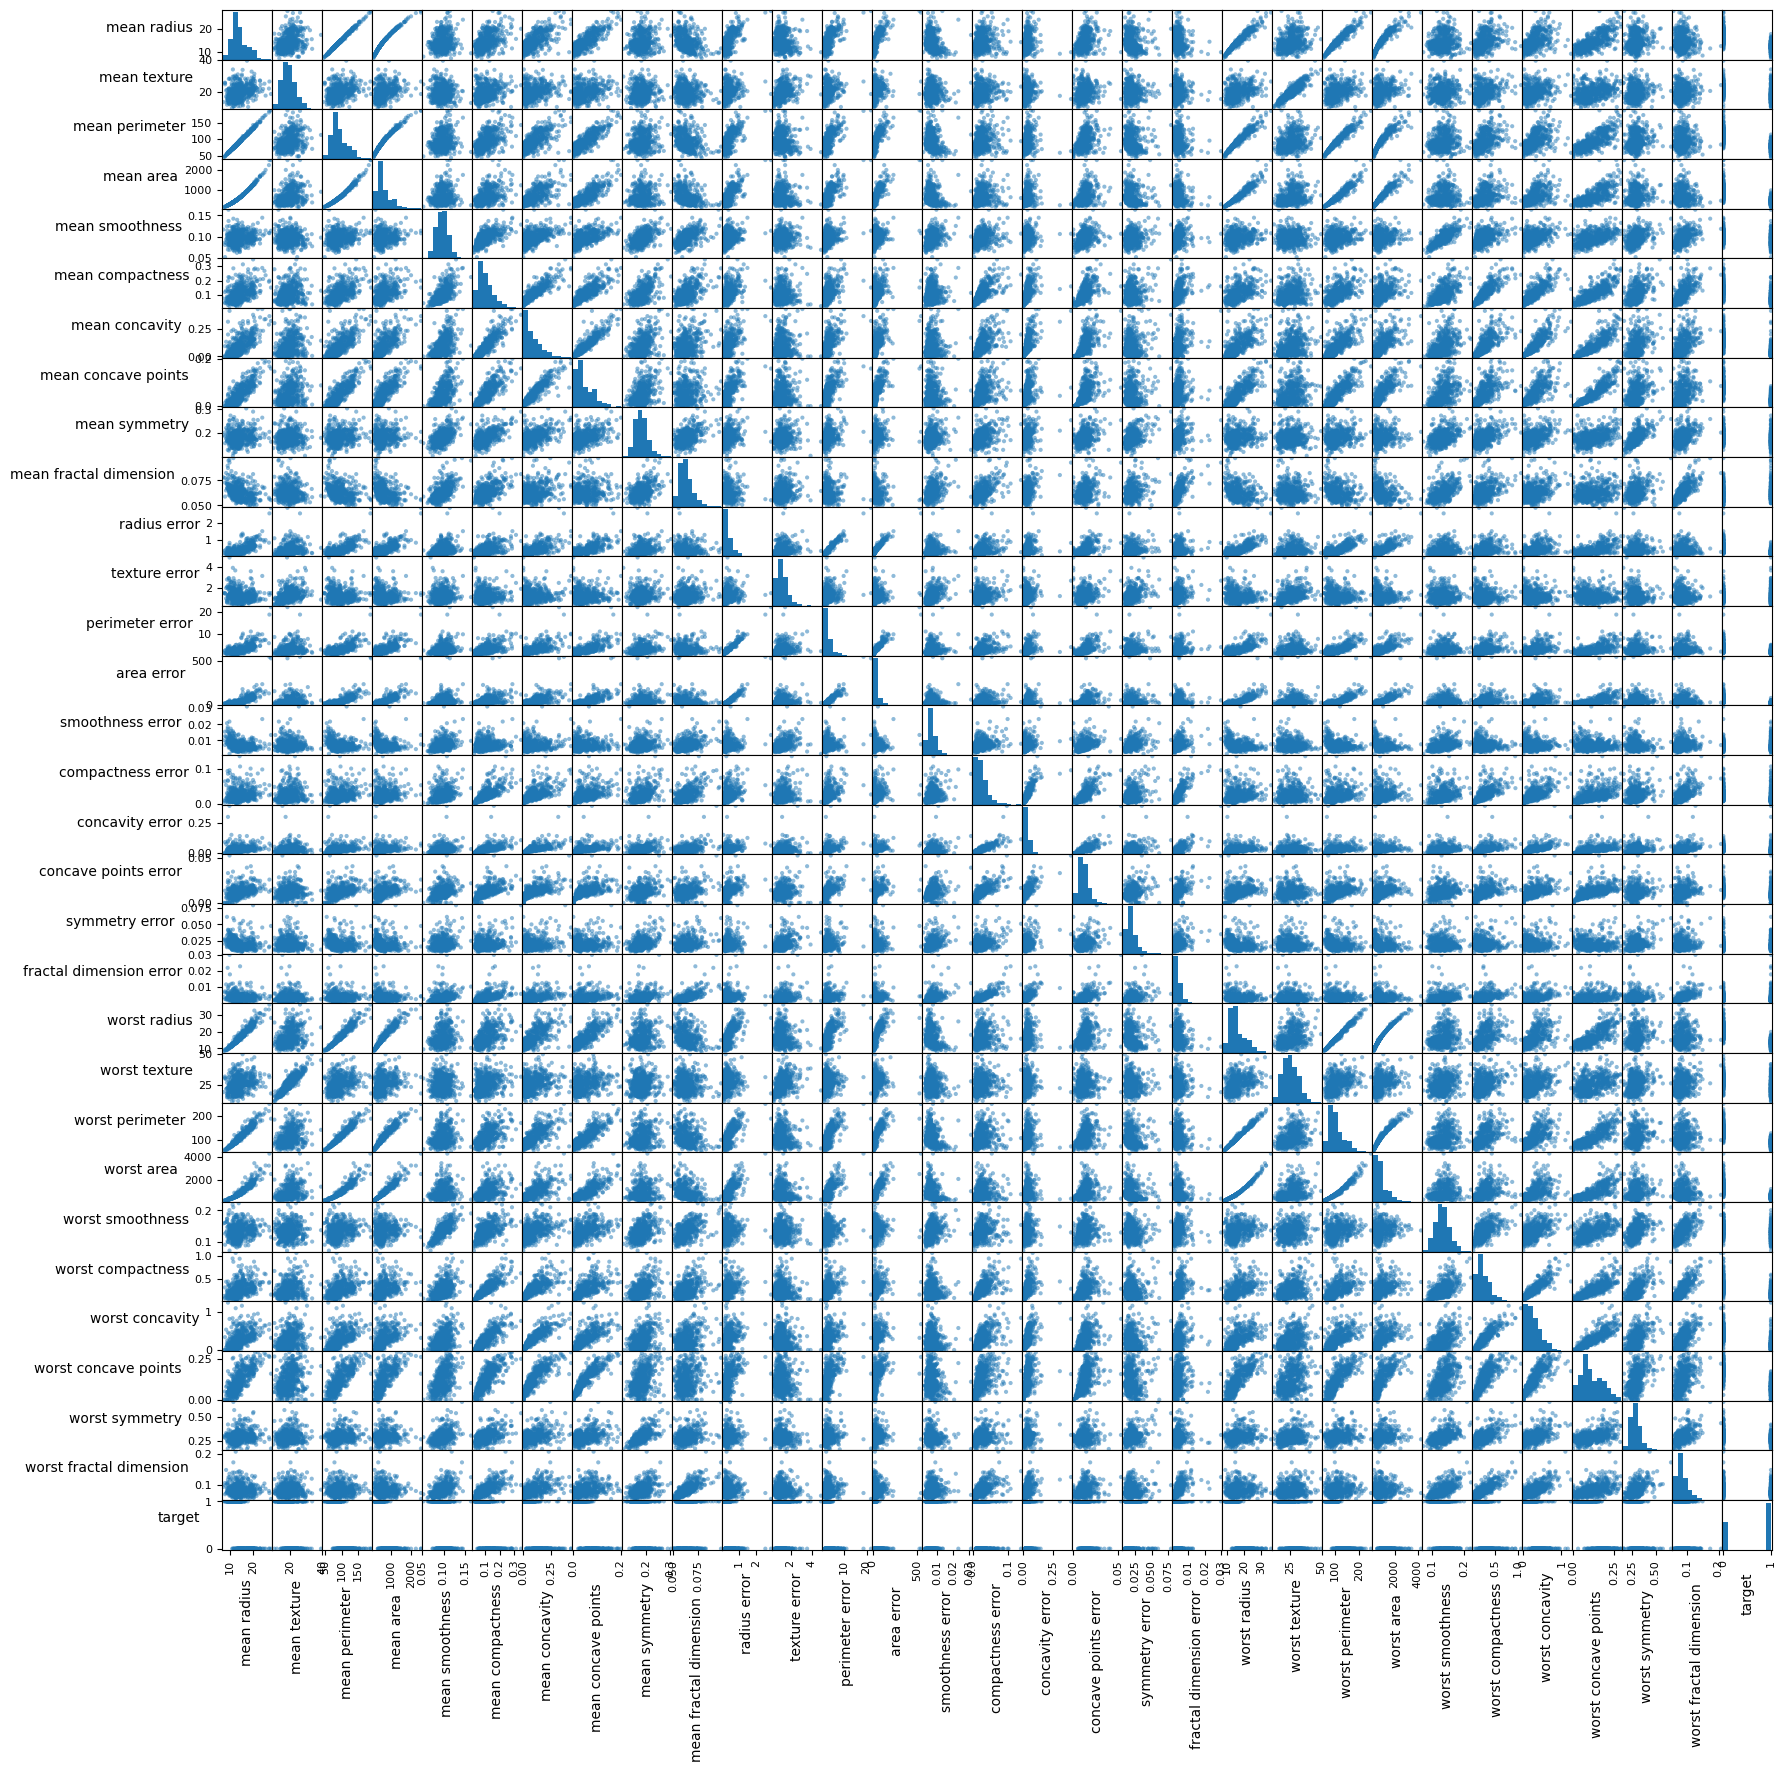

In [7]:
fig = scatter_matrix(df, figsize=(20,20))
for ax in fig.ravel():
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), rotation=90)
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), rotation=0, ha='right')

In [8]:
X = cancer.data
y = cancer.target

# Split of the test set 
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.25
                                                          ,stratify=y, random_state=123) 

In [9]:
# function to get evaluation metrics
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    tp, fp, fn, tn = confusion_matrix(y_true, y_pred).ravel() # ravel flattens the matrix
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    return accuracy, sensitivity, specificity, f1

In [10]:
# TODO: pipeline?

k_values = [3, 5, 7, 10, 15]

param_grid = {
    'n_estimators': [10, 50, 100], # number of trees in the forest
    'max_features': ['sqrt', 'log2', None], # number of features to consider at every split
    'max_depth': [10, 20, 30], # maximum number of levels in each decision tree
    'min_samples_split': [2, 5, 10], # minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4], # minimum number of samples required at each leaf node
    'bootstrap': [True, False] # resampling
}

results = {}

for k in k_values:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=123)

    fold_results = []
    
    for train_i, val_i in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval[train_i], X_trainval[val_i]
        y_train, y_val = y_trainval[train_i], y_trainval[val_i]
        
        rfc = RandomForestClassifier(random_state=123)
        
        grid_random_search = RandomizedSearchCV(
            estimator=rfc
            ,param_distributions=param_grid
            ,cv=5
            ,return_train_score=True
            ,random_state=123
            ,scoring='f1'
            )
        
        grid_random_search.fit(X_train, y_train)

        best_model = grid_random_search.best_estimator_

        # evaluate best model
        y_pred = best_model.predict(X_val)

        # evaluation metrics
        accuracy, sensitivity, specificity, f1 = evaluate_model(y_val, y_pred)

        fold_results.append((accuracy, sensitivity, specificity, f1, grid_random_search.best_params_))


    results[k] = fold_results

In [11]:
for k, scores in results.items():
    accuracy, sensitivity, specificity, f1, best_params = scores[0]
    print(f'\nk={k}\tAccuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}, F1-Score: {f1:.4f}\n\tBest Parameters: {best_params}')



k=3	Accuracy: 0.9577, Sensitivity: 0.9796, Specificity: 0.9462, F1-Score: 0.9670
	Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}

k=5	Accuracy: 0.9535, Sensitivity: 1.0000, Specificity: 0.9310, F1-Score: 0.9643
	Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}

k=7	Accuracy: 0.9180, Sensitivity: 0.9474, Specificity: 0.9048, F1-Score: 0.9383
	Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}

k=10	Accuracy: 0.9535, Sensitivity: 1.0000, Specificity: 0.9310, F1-Score: 0.9643
	Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}

k=15	Accuracy: 0.9310, Sensitivity: 1.0000, Specificity: 0.9000, F1-Score: 0.9474


In [12]:
# get parameters of k with highest f1 score
k_best_f1 = max(results, key=lambda k: results[k][0][3])
params_best_f1 = results[k_best_f1][0][4]

print(f'Best params for k={k_best_f1} with highest F1-Score: {params_best_f1}')

Best params for k=3 with highest F1-Score: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}


In [13]:
# evaluate the best model
rfc = RandomForestClassifier(random_state=123, **params_best_f1) # can input the best parameters

rfc.fit(X_trainval, y_trainval)
y_test_pred = rfc.predict(X_test)

accuracy, sensitivity, specificity, f1 = evaluate_model(y_test, y_test_pred)

print(f'Test Set Evaluation ({k_best_f1}):\nAccuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}, F1-Score: {f1:.4f}')


Test Set Evaluation (3):
Accuracy: 0.9720, Sensitivity: 0.9804, Specificity: 0.9674, F1-Score: 0.9780
